In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="darkgrid")

with open("portfolio_data.pkl", "rb") as f:
    data = pickle.load(f)

prices            = data["prices"]
log_returns       = data["log_returns"]
portfolio_returns = data["portfolio_returns"]
weights           = data["weights"]
tickers           = data["tickers"]
hs_var            = data["hs_var"]
hs_cvar           = data["hs_cvar"]
conf_levels       = data["conf_levels"]

print("Loaded successfully.")
print(f"Tickers  : {tickers}")
print(f"Weights  : {weights.round(4)}")
print(f"Date range: {log_returns.index[0].date()} → {log_returns.index[-1].date()}")

Loaded successfully.
Tickers  : ['SPY', 'QQQ', 'EFA', 'GLD', 'TLT', 'LQD', 'XOM', 'VNQ']
Weights  : [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
Date range: 2015-01-05 → 2024-12-30


In [3]:
import os

_cwd = os.getcwd()
_proj_root = _cwd if os.path.exists(os.path.join(_cwd, "README.md")) else os.path.dirname(_cwd)
RESULTS = os.path.join(_proj_root, "results", "phase_5_stress_testing")
os.makedirs(RESULTS, exist_ok=True)
print(f"Results folder: {RESULTS}")

Results folder: c:\Users\kshit\VaR CVaR\results\phase_5_stress_testing


In [ ]:
def portfolio_loss(shocks: np.ndarray, weights: np.ndarray) -> float:
    """
    shocks  : 1D array of asset log returns (negative = loss)
    weights : portfolio weights
    Returns portfolio loss as a POSITIVE number (loss convention)
    """
    return -float(np.dot(weights, shocks))


def dollar_loss(loss_pct: float, portfolio_value: float = 1_000_000) -> float:
    return loss_pct * portfolio_value

In [ ]:
gfc_shocks = {
    "SPY": -0.55,   # S&P 500: -55% peak to trough
    "QQQ": -0.49,   # Nasdaq-100: -49%
    "EFA": -0.57,   # International developed: -57%
    "GLD": +0.25,   # Gold: +25% (flight to safety)
    "TLT": +0.26,   # Long treasuries: +26% (flight to quality)
    "LQD": -0.15,   # Investment grade credit: -15% (spread widening)
    "XOM": -0.38,   # Energy: -38%
    "VNQ": -0.68,   # REITs: -68% (worst hit sector)
}

shock_vector = np.array([gfc_shocks[t] for t in tickers])

N_GFC_DAYS     = 126
daily_shocks   = shock_vector / N_GFC_DAYS     # approx equal daily drawdown
gfc_daily_rets = np.tile(daily_shocks, (N_GFC_DAYS, 1))   # shape (126, 8)
gfc_window     = pd.DataFrame(
    gfc_daily_rets, columns=tickers,
    index=pd.bdate_range("2008-09-15", periods=N_GFC_DAYS)
)

print("GFC scenario: using documented crisis drawdowns (data not available pre-2015)")
print(f"Simulated window: {N_GFC_DAYS} trading days")
print(f"\nAsset total shocks applied:")
for t, s in gfc_shocks.items():
    print(f"  {t:6s}: {s*100:+.1f}%")

GFC scenario: using documented crisis drawdowns (data not available pre-2015)
Simulated window: 126 trading days

Asset total shocks applied:
  SPY   : -55.0%
  QQQ   : -49.0%
  EFA   : -57.0%
  GLD   : +25.0%
  TLT   : +26.0%
  LQD   : -15.0%
  XOM   : -38.0%
  VNQ   : -68.0%


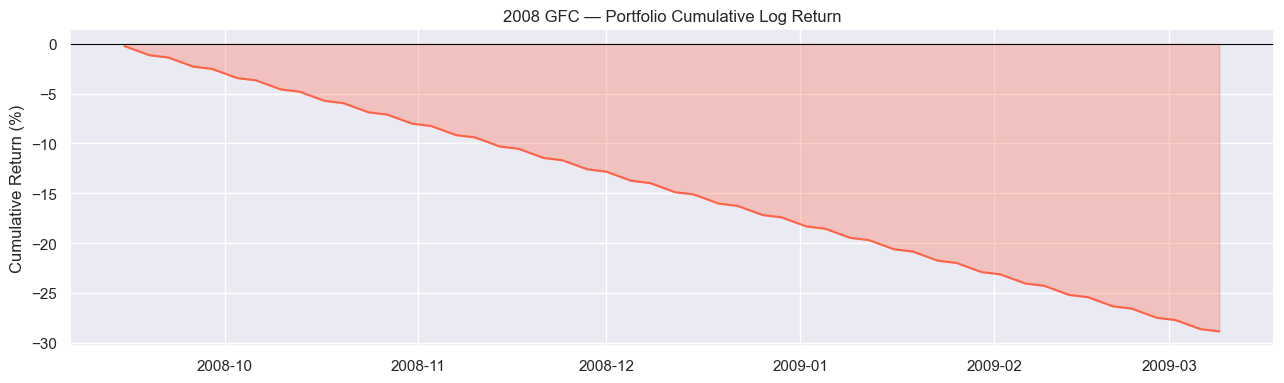


GFC Stress Metrics:
  Total loss (window)  : +28.88%  → $288,750
  Peak drawdown        : +28.88%  → $288,750
  Worst single day     : +0.23%  → $2,292
  Avg daily loss       : +0.23%  → $2,292

  99% HS VaR (1-day)   : 1.89%   → $18,887
  99% HS CVaR (1-day)  : 3.18%   → $31,791
  Worst GFC day vs VaR : 0.12x the 99% VaR


In [6]:
gfc_portfolio = gfc_window.dot(weights)
gfc_cumulative_port = gfc_portfolio.cumsum()

plt.figure(figsize=(13, 4))
plt.plot(gfc_cumulative_port.index, gfc_cumulative_port * 100,
         color="tomato", linewidth=1.5)
plt.fill_between(gfc_cumulative_port.index, gfc_cumulative_port * 100, 0,
                 color="tomato", alpha=0.3)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("2008 GFC — Portfolio Cumulative Log Return")
plt.ylabel("Cumulative Return (%)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "01_gfc_drawdown.png"), dpi=150, bbox_inches="tight")
plt.show()

gfc_peak_loss   = -gfc_cumulative_port.min()
gfc_total_loss  = -gfc_cumulative_port.iloc[-1]
gfc_worst_day   = -gfc_portfolio.min()
gfc_mean_daily  = -gfc_portfolio.mean()

print(f"\nGFC Stress Metrics:")
print(f"  Total loss (window)  : {gfc_total_loss*100:+.2f}%  → ${dollar_loss(gfc_total_loss):,.0f}")
print(f"  Peak drawdown        : {gfc_peak_loss*100:+.2f}%  → ${dollar_loss(gfc_peak_loss):,.0f}")
print(f"  Worst single day     : {gfc_worst_day*100:+.2f}%  → ${dollar_loss(gfc_worst_day):,.0f}")
print(f"  Avg daily loss       : {gfc_mean_daily*100:+.2f}%  → ${dollar_loss(gfc_mean_daily):,.0f}")
print(f"\n  99% HS VaR (1-day)   : {hs_var[0.99]*100:.2f}%   → ${dollar_loss(hs_var[0.99]):,.0f}")
print(f"  99% HS CVaR (1-day)  : {hs_cvar[0.99]*100:.2f}%   → ${dollar_loss(hs_cvar[0.99]):,.0f}")
print(f"  Worst GFC day vs VaR : {gfc_worst_day/hs_var[0.99]:.2f}x the 99% VaR")

COVID window: 2020-02-20 → 2020-03-23
Trading days: 23


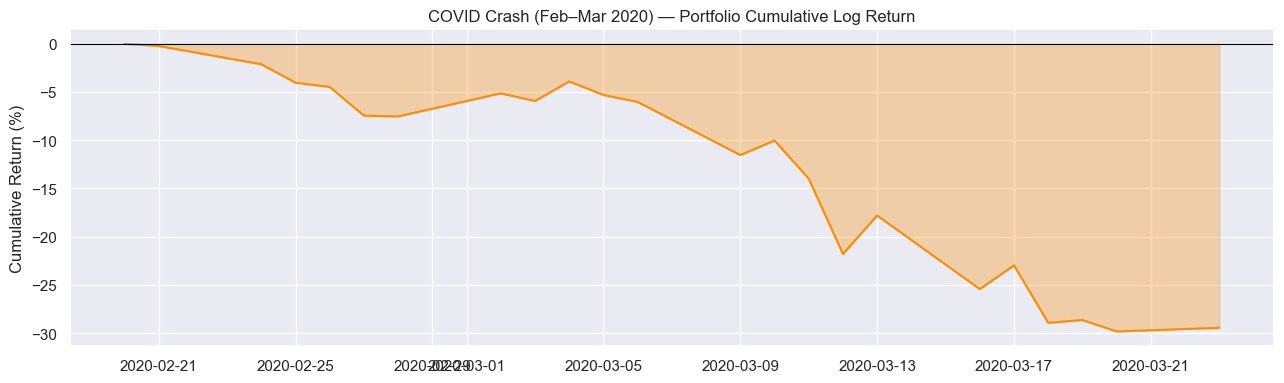


COVID Stress Metrics:
  Total loss (window)  : +29.46%  → $294,565
  Peak drawdown        : +29.83%  → $298,348
  Worst single day     : +7.81%  → $78,102
  Avg daily loss       : +1.28%  → $12,807

  99% HS VaR (1-day)   : 1.89%   → $18,887
  Worst COVID day vs VaR: 4.14x the 99% VaR


In [7]:
covid_start = "2020-02-20"
covid_end   = "2020-03-23"

covid_window    = log_returns.loc[covid_start:covid_end]
covid_portfolio = covid_window.dot(weights)
covid_cumulative_port = covid_portfolio.cumsum()

print(f"COVID window: {covid_window.index[0].date()} → {covid_window.index[-1].date()}")
print(f"Trading days: {len(covid_window)}")

plt.figure(figsize=(13, 4))
plt.plot(covid_cumulative_port.index, covid_cumulative_port * 100,
         color="darkorange", linewidth=1.5)
plt.fill_between(covid_cumulative_port.index, covid_cumulative_port * 100, 0,
                 color="darkorange", alpha=0.3)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("COVID Crash (Feb–Mar 2020) — Portfolio Cumulative Log Return")
plt.ylabel("Cumulative Return (%)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "02_covid_crash_drawdown.png"), dpi=150, bbox_inches="tight")
plt.show()

covid_peak_loss  = -covid_cumulative_port.min()
covid_total_loss = -covid_cumulative_port.iloc[-1]
covid_worst_day  = -covid_portfolio.min()
covid_mean_daily = -covid_portfolio.mean()

print(f"\nCOVID Stress Metrics:")
print(f"  Total loss (window)  : {covid_total_loss*100:+.2f}%  → ${dollar_loss(covid_total_loss):,.0f}")
print(f"  Peak drawdown        : {covid_peak_loss*100:+.2f}%  → ${dollar_loss(covid_peak_loss):,.0f}")
print(f"  Worst single day     : {covid_worst_day*100:+.2f}%  → ${dollar_loss(covid_worst_day):,.0f}")
print(f"  Avg daily loss       : {covid_mean_daily*100:+.2f}%  → ${dollar_loss(covid_mean_daily):,.0f}")
print(f"\n  99% HS VaR (1-day)   : {hs_var[0.99]*100:.2f}%   → ${dollar_loss(hs_var[0.99]):,.0f}")
print(f"  Worst COVID day vs VaR: {covid_worst_day/hs_var[0.99]:.2f}x the 99% VaR")

Rate Shock window: 2022-01-03 → 2022-10-13
Trading days: 197


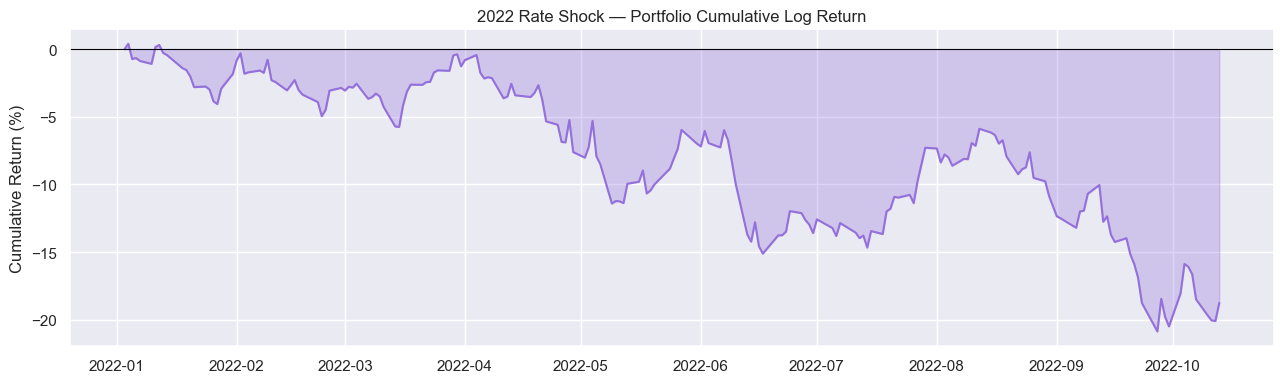


Rate Shock Stress Metrics:
  Total loss (window)  : +18.75%  → $187,521
  Peak drawdown        : +20.86%  → $208,623
  Worst single day     : +3.75%  → $37,526
  Avg daily loss       : +0.10%  → $952

Asset cumulative returns over Rate Shock window:
  SPY   : -24.92%
  QQQ   : -38.71%
  EFA   : -30.29%
  GLD   : -9.86%
  TLT   : -38.34%
  LQD   : -24.62%
  XOM   : +54.06%
  VNQ   : -37.34%


In [8]:
rate_start = "2022-01-03"
rate_end   = "2022-10-13"

rate_window    = log_returns.loc[rate_start:rate_end]
rate_portfolio = rate_window.dot(weights)
rate_cumulative_port = rate_portfolio.cumsum()

print(f"Rate Shock window: {rate_window.index[0].date()} → {rate_window.index[-1].date()}")
print(f"Trading days: {len(rate_window)}")

plt.figure(figsize=(13, 4))
plt.plot(rate_cumulative_port.index, rate_cumulative_port * 100,
         color="mediumpurple", linewidth=1.5)
plt.fill_between(rate_cumulative_port.index, rate_cumulative_port * 100, 0,
                 color="mediumpurple", alpha=0.3)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("2022 Rate Shock — Portfolio Cumulative Log Return")
plt.ylabel("Cumulative Return (%)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "03_rate_shock_drawdown.png"), dpi=150, bbox_inches="tight")
plt.show()

rate_peak_loss  = -rate_cumulative_port.min()
rate_total_loss = -rate_cumulative_port.iloc[-1]
rate_worst_day  = -rate_portfolio.min()
rate_mean_daily = -rate_portfolio.mean()

print(f"\nRate Shock Stress Metrics:")
print(f"  Total loss (window)  : {rate_total_loss*100:+.2f}%  → ${dollar_loss(rate_total_loss):,.0f}")
print(f"  Peak drawdown        : {rate_peak_loss*100:+.2f}%  → ${dollar_loss(rate_peak_loss):,.0f}")
print(f"  Worst single day     : {rate_worst_day*100:+.2f}%  → ${dollar_loss(rate_worst_day):,.0f}")
print(f"  Avg daily loss       : {rate_mean_daily*100:+.2f}%  → ${dollar_loss(rate_mean_daily):,.0f}")

print(f"\nAsset cumulative returns over Rate Shock window:")
for t, r in rate_window.sum().items():
    print(f"  {t:6s}: {r*100:+.2f}%")

In [9]:
# A forward-looking scenario — not based on history.
# Simulates a sudden liquidity crisis / flash crash:
#   Equities  -15%  (SPY, QQQ, EFA, XOM, VNQ)
#   Gold      +5%   (flight to safety)
#   Bonds     -5%   (forced selling / liquidity crunch)
#   Credit    -8%   (spread widening)
#
# This is the kind of scenario a risk committee would design
# based on macro tail risks, not past data.

hypothetical_shocks = {
    "SPY": -0.15,
    "QQQ": -0.15,
    "EFA": -0.15,
    "GLD": +0.05,
    "TLT": -0.05,
    "LQD": -0.08,
    "XOM": -0.15,
    "VNQ": -0.15,
}

shock_vector   = np.array([hypothetical_shocks[t] for t in tickers])
hypo_loss      = portfolio_loss(shock_vector, weights)

print("── Hypothetical Shock Scenario ──────────────────────────")
print("\nAsset-level shocks:")
for t, s in hypothetical_shocks.items():
    print(f"  {t:6s}: {s*100:+.1f}%")

print(f"\nPortfolio loss          : {hypo_loss*100:.2f}%")
print(f"Dollar loss ($1M)       : ${dollar_loss(hypo_loss):,.0f}")
print(f"vs 99% VaR              : {hypo_loss/hs_var[0.99]:.2f}x")
print(f"vs 99% CVaR             : {hypo_loss/hs_cvar[0.99]:.2f}x")

── Hypothetical Shock Scenario ──────────────────────────

Asset-level shocks:
  SPY   : -15.0%
  QQQ   : -15.0%
  EFA   : -15.0%
  GLD   : +5.0%
  TLT   : -5.0%
  LQD   : -8.0%
  XOM   : -15.0%
  VNQ   : -15.0%

Portfolio loss          : 10.38%
Dollar loss ($1M)       : $103,750
vs 99% VaR              : 5.49x
vs 99% CVaR             : 3.26x


In [10]:
PV = 1_000_000

scenarios = {
    "GFC (2008–09)":        {"1-Day Worst (%)": gfc_worst_day*100,
                              "Total Loss (%)":  gfc_total_loss*100,
                              "1-Day Worst ($)": dollar_loss(gfc_worst_day, PV),
                              "Total Loss ($)":  dollar_loss(gfc_total_loss, PV),
                              "vs 99% VaR":      gfc_worst_day/hs_var[0.99]},
    "COVID (2020)":          {"1-Day Worst (%)": covid_worst_day*100,
                              "Total Loss (%)":  covid_total_loss*100,
                              "1-Day Worst ($)": dollar_loss(covid_worst_day, PV),
                              "Total Loss ($)":  dollar_loss(covid_total_loss, PV),
                              "vs 99% VaR":      covid_worst_day/hs_var[0.99]},
    "Rate Shock (2022)":     {"1-Day Worst (%)": rate_worst_day*100,
                              "Total Loss (%)":  rate_total_loss*100,
                              "1-Day Worst ($)": dollar_loss(rate_worst_day, PV),
                              "Total Loss ($)":  dollar_loss(rate_total_loss, PV),
                              "vs 99% VaR":      rate_worst_day/hs_var[0.99]},
    "Hypothetical Shock":    {"1-Day Worst (%)": hypo_loss*100,
                              "Total Loss (%)":  hypo_loss*100,
                              "1-Day Worst ($)": dollar_loss(hypo_loss, PV),
                              "Total Loss ($)":  dollar_loss(hypo_loss, PV),
                              "vs 99% VaR":      hypo_loss/hs_var[0.99]},
}

# Add VaR/CVaR as reference rows
scenarios["── 99% VaR (ref)"]  = {"1-Day Worst (%)": hs_var[0.99]*100,
                                    "Total Loss (%)":  hs_var[0.99]*100,
                                    "1-Day Worst ($)": dollar_loss(hs_var[0.99], PV),
                                    "Total Loss ($)":  dollar_loss(hs_var[0.99], PV),
                                    "vs 99% VaR":      1.0}
scenarios["── 99% CVaR (ref)"] = {"1-Day Worst (%)": hs_cvar[0.99]*100,
                                    "Total Loss (%)":  hs_cvar[0.99]*100,
                                    "1-Day Worst ($)": dollar_loss(hs_cvar[0.99], PV),
                                    "Total Loss ($)":  dollar_loss(hs_cvar[0.99], PV),
                                    "vs 99% VaR":      hs_cvar[0.99]/hs_var[0.99]}

scen_df = pd.DataFrame(scenarios).T
scen_df["1-Day Worst (%)"] = scen_df["1-Day Worst (%)"].map(lambda x: f"{x:.2f}%")
scen_df["Total Loss (%)"]  = scen_df["Total Loss (%)"].map(lambda x: f"{x:.2f}%")
scen_df["1-Day Worst ($)"] = scen_df["1-Day Worst ($)"].map(lambda x: f"${x:,.0f}")
scen_df["Total Loss ($)"]  = scen_df["Total Loss ($)"].map(lambda x: f"${x:,.0f}")
scen_df["vs 99% VaR"]      = scen_df["vs 99% VaR"].map(lambda x: f"{x:.2f}x")

print("── Stress Test vs VaR/CVaR Summary ─────────────────────")
scen_df

── Stress Test vs VaR/CVaR Summary ─────────────────────


,1-Day Worst (%),Total Loss (%),1-Day Worst ($),Total Loss ($),vs 99% VaR
GFC (2008–09),0.23%,28.88%,"$2,292","$288,750",0.12x
COVID (2020),7.81%,29.46%,"$78,102","$294,565",4.14x
Rate Shock (2022),3.75%,18.75%,"$37,526","$187,521",1.99x
Hypothetical Shock,10.38%,10.38%,"$103,750","$103,750",5.49x
── 99% VaR (ref),1.89%,1.89%,"$18,887","$18,887",1.00x
── 99% CVaR (ref),3.18%,3.18%,"$31,791","$31,791",1.68x


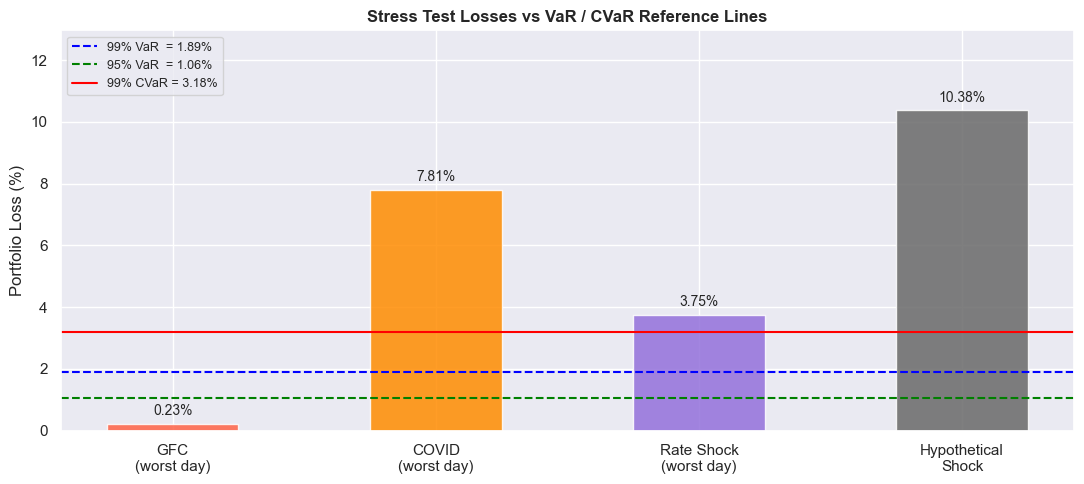

In [11]:
labels      = ["GFC\n(worst day)", "COVID\n(worst day)",
               "Rate Shock\n(worst day)", "Hypothetical\nShock"]
losses_pct  = [gfc_worst_day*100, covid_worst_day*100,
               rate_worst_day*100, hypo_loss*100]
bar_colors  = ["tomato", "darkorange", "mediumpurple", "dimgray"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, losses_pct, color=bar_colors, alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.2f%%", padding=4, fontsize=10)

ax.axhline(hs_var[0.99]  * 100, color="blue",  linewidth=1.5,
           linestyle="--", label=f"99% VaR  = {hs_var[0.99]*100:.2f}%")
ax.axhline(hs_var[0.95]  * 100, color="green", linewidth=1.5,
           linestyle="--", label=f"95% VaR  = {hs_var[0.95]*100:.2f}%")
ax.axhline(hs_cvar[0.99] * 100, color="red",   linewidth=1.5,
           linestyle="-",  label=f"99% CVaR = {hs_cvar[0.99]*100:.2f}%")

ax.set_title("Stress Test Losses vs VaR / CVaR Reference Lines",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Portfolio Loss (%)")
ax.legend(fontsize=9)
ax.set_ylim(0, max(losses_pct) * 1.25)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "04_stress_test_vs_var.png"), dpi=150, bbox_inches="tight")
plt.show()

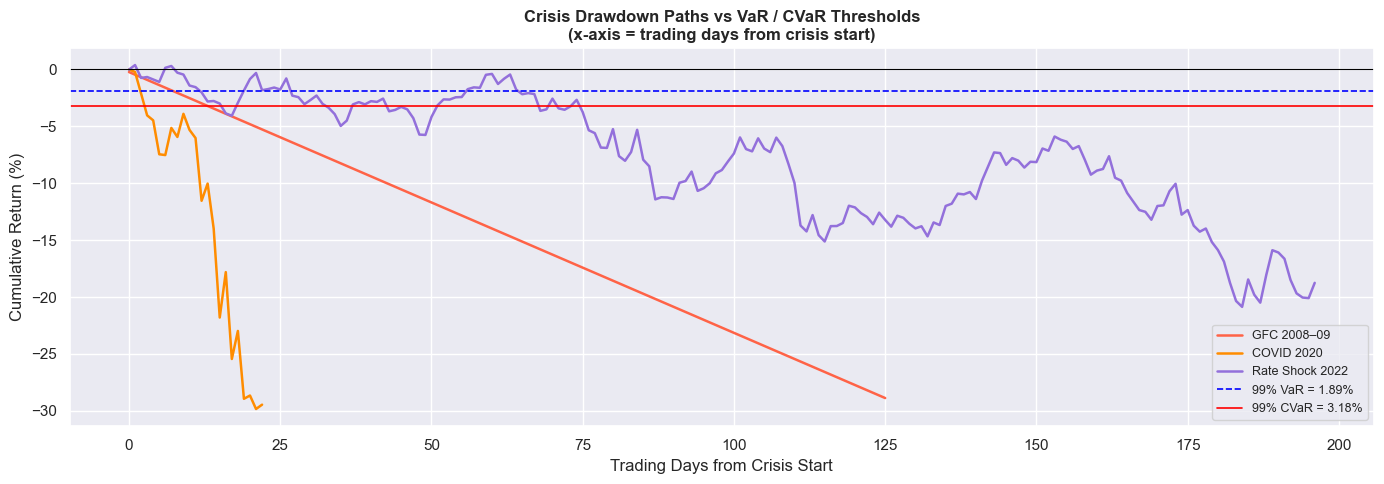

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

scenarios_plot = {
    "GFC 2008–09":    gfc_cumulative_port.values,
    "COVID 2020":     covid_cumulative_port.values,
    "Rate Shock 2022":rate_cumulative_port.values,
}
colors = ["tomato", "darkorange", "mediumpurple"]

for (label, vals), color in zip(scenarios_plot.items(), colors):
    ax.plot(range(len(vals)), vals * 100,
            color=color, linewidth=1.8, label=label)

ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(-hs_var[0.99]  * 100, color="blue", linewidth=1.2, linestyle="--",
           label=f"99% VaR = {hs_var[0.99]*100:.2f}%")
ax.axhline(-hs_cvar[0.99] * 100, color="red",  linewidth=1.2, linestyle="-",
           label=f"99% CVaR = {hs_cvar[0.99]*100:.2f}%")

ax.set_title("Crisis Drawdown Paths vs VaR / CVaR Thresholds\n(x-axis = trading days from crisis start)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Trading Days from Crisis Start")
ax.set_ylabel("Cumulative Return (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "05_crisis_paths_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [13]:
stress_results = {
    "gfc_portfolio":         gfc_portfolio,
    "gfc_cumulative":        gfc_cumulative_port,
    "covid_portfolio":       covid_portfolio,
    "covid_cumulative":      covid_cumulative_port,
    "rate_portfolio":        rate_portfolio,
    "rate_cumulative":       rate_cumulative_port,
    "hypo_loss":             hypo_loss,
    "stress_worst_days": {
        "GFC":          gfc_worst_day,
        "COVID":        covid_worst_day,
        "Rate Shock":   rate_worst_day,
        "Hypothetical": hypo_loss,
    },
    "stress_total_losses": {
        "GFC":        gfc_total_loss,
        "COVID":      covid_total_loss,
        "Rate Shock": rate_total_loss,
    },
}

data.update(stress_results)

with open("portfolio_data.pkl", "wb") as f:
    pickle.dump(data, f)

print("portfolio_data.pkl updated with Phase 5 stress testing results.")

portfolio_data.pkl updated with Phase 5 stress testing results.
